In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

In [4]:
from sklearn.decomposition import TruncatedSVD

In [5]:
df = pd.read_csv("/Users/senuja/Jupyter Notebook/Video_Game_Sales_Predictor/data/external/5. Feature Selection/Feature Selection(1-hot).csv")

In [6]:
df.head()

,Game Title,Critic Score,Sales,North American Sales,Japanese Sales,EU Sales,Other Sales,Release Year,Genre_Action-Adventure,Genre_Adventure,...,Developer_Vicarious Visions,Developer_Visual Concepts,Decade,NA Share,EU Share,JP Share,Other Share,Is Recent,Game Quality,Game Quality Encoded
0,Spider-Man: Mysterio's Menace,0.701367,1.0,0.741379,0.000000,0.280702,0.017544,2001,0,0,...,1,0,2000,0.704918,0.262295,0.000000,0.016393,0,High,2
1,Tomb Raider Chronicles,0.701367,1.0,0.586207,0.000000,0.403509,0.070175,2000,0,0,...,0,0,2000,0.557377,0.377049,0.000000,0.065574,0,High,2
2,Tony Hawk: RIDE,0.402299,1.0,0.655172,0.000000,0.263158,0.140351,2009,0,0,...,0,0,2000,0.622951,0.245902,0.000000,0.131148,0,Medium,1
3,Advance Wars: Days of Ruin,0.850575,1.0,0.741379,0.000000,0.228070,0.087719,2008,0,0,...,0,0,2000,0.704918,0.213115,0.000000,0.081967,0,High,2
4,New Play Control! Pikmin 2,0.885057,1.0,0.189655,0.557377,0.228070,0.035088,2012,0,0,...,0,0,2010,0.180328,0.213115,0.557377,0.032787,0,High,2


In [7]:
df.dtypes # check data types

Game Title               object
Critic Score            float64
Sales                   float64
North American Sales    float64
Japanese Sales          float64
                         ...   
JP Share                float64
Other Share             float64
Is Recent                 int64
Game Quality             object
Game Quality Encoded      int64
Length: 133, dtype: object

In [8]:
# 1) Build numeric matrix (drop target), clean, and make floats
X = df.drop(columns=["Sales"]).select_dtypes(include=["number", "bool"]).copy()
X = X.replace([np.inf, -np.inf], np.nan).fillna(0)
X = X.astype(float)

In [9]:
# 2) Find K to hit ~90% variance
max_k = min(50, X.shape[1] - 1) if X.shape[1] > 1 else 1
svd_probe = TruncatedSVD(n_components=max_k, random_state=42)
svd_probe.fit(X)
cumvar = svd_probe.explained_variance_ratio_.cumsum()

# Auto-pick K
K = int(np.searchsorted(cumvar, 0.90) + 1) if X.shape[1] > 1 else 1
K = max(2, min(K, max_k))
print("Chosen components K =", K, "| Cumulative variance ≈", round(cumvar[K-1], 4))

Chosen components K = 2 | Cumulative variance ≈ 0.9558


In [10]:
# 3) Final SVD transform
svd = TruncatedSVD(n_components=K, random_state=42)
Z = svd.fit_transform(X)
comp_cols = [f"SVD_{i+1}" for i in range(K)]

In [11]:
# 4) OVERWRITE df with reduced components + Sales
df = pd.concat(
    [df[["Sales"]].reset_index(drop=True),
     pd.DataFrame(Z, columns=comp_cols)],
    axis=1
)

print("AFTER  (rows, cols):", df.shape)
display(df.head())

AFTER  (rows, cols): (14897, 3)


,Sales,SVD_1,SVD_2
0,1.0,2829.133784,2.746284
1,1.0,2828.426061,3.434086
2,1.0,2834.797048,-2.890891
3,1.0,2834.089860,-2.226003
4,1.0,2843.984148,2.033736


In [12]:
df.head()

# SVD_1 - a weighted mix of many original features (genre, console, publisher, critic score, etc.) 
        # chosen to capture the largest possible variance

#SVD_2 - another mix of features, capturing the second-most variance

,Sales,SVD_1,SVD_2
0,1.0,2829.133784,2.746284
1,1.0,2828.426061,3.434086
2,1.0,2834.797048,-2.890891
3,1.0,2834.089860,-2.226003
4,1.0,2843.984148,2.033736


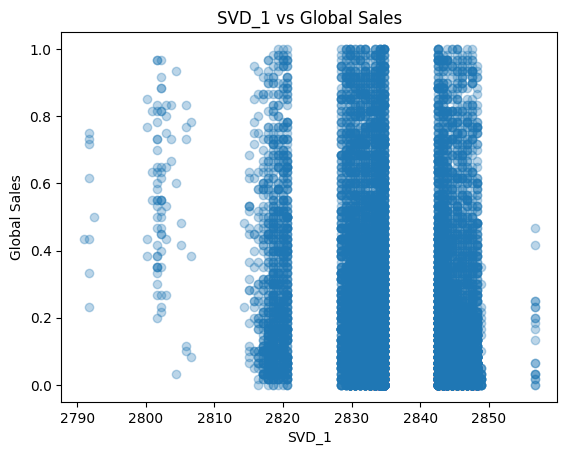

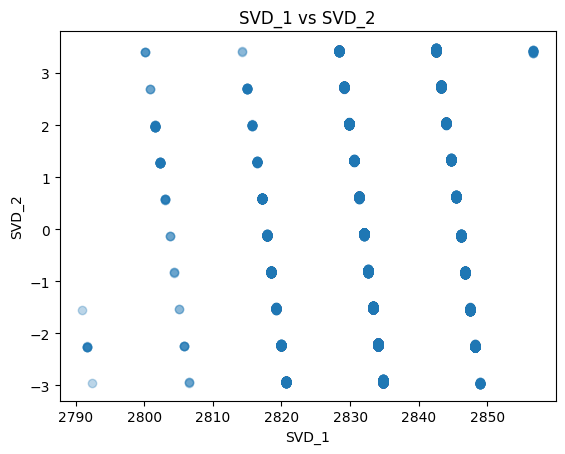

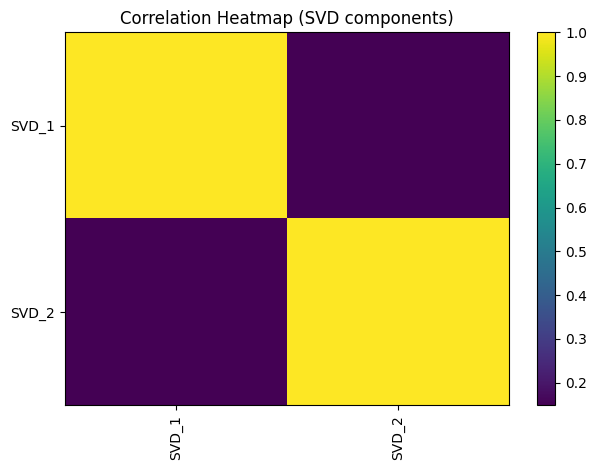

In [13]:

# 1) SVD_1 vs Sales
svd_cols = [c for c in df.columns if c.startswith("SVD_")]
if svd_cols:
    plt.figure()
    plt.scatter(df[svd_cols[0]], df['Sales'], alpha=0.3)
    plt.title("SVD_1 vs Global Sales")
    plt.xlabel("SVD_1")
    plt.ylabel("Global Sales")
    plt.show()

# 2) SVD_1 vs SVD_2
if len(svd_cols) >= 2:
    plt.figure()
    plt.scatter(df[svd_cols[0]], df[svd_cols[1]], alpha=0.3)
    plt.title("SVD_1 vs SVD_2")
    plt.xlabel("SVD_1")
    plt.ylabel("SVD_2")
    plt.show()

# 3) Correlation among SVD components (optional)
corr = df[svd_cols].corr()
plt.figure()
plt.imshow(corr.values, aspect='auto')
plt.title("Correlation Heatmap (SVD components)")
plt.xticks(range(corr.shape[1]), corr.columns, rotation=90)
plt.yticks(range(corr.shape[0]), corr.index)
plt.colorbar()
plt.tight_layout()
plt.show()


In [14]:
df.to_csv("/Users/senuja/Jupyter Notebook/Video_Game_Sales_Predictor/data/external/6. Dimensionality Reduction/Dimensionality Reduction.csv", index=False)